**LAB1: Dataset Exploration**

Dataset: heart disease predication dataset  
Reference Link: https://www.kaggle.com/datasets/miadul/heat-disease-predication-dataset

**1.1 Load Data**

In [10]:
#Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\ML\data\synthetic_heart_disease_dataset.csv")

**1.2 Display Shape**  
This section checks the dataset shape to identify the total number of rows and columns, providing an understanding of the data dimensions before proceeding with data preprocessing.

In [4]:
#Display Shape
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 21)


**1.3 Display Data Types**  
This section inspects the data type of each column in the dataset.

In [5]:
df.dtypes.to_frame(name='dtype')

,dtype
Age,int64
Gender,str
Weight,int64
Height,int64
BMI,float64
Smoking,str
Alcohol_Intake,str
Physical_Activity,str
Diet,str
Stress_Level,str


- Integer features (int64): 14 columns
- Floating-point features (float64): 1 column
- Text/String features (object/str): 6 columns

**1.4 Display Summary Statistics**  
Display the baseline statistical summary of the dataset.

In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,50000.0,NaN,NaN,NaN,54.46406,14.43809,30.0,42.0,54.0,67.0,79.0
Gender,50000,2,Female,25110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weight,50000.0,NaN,NaN,NaN,84.54752,20.213257,50.0,67.0,85.0,102.0,119.0
Height,50000.0,NaN,NaN,NaN,174.46,14.420379,150.0,162.0,174.0,187.0,199.0
BMI,50000.0,NaN,NaN,NaN,28.984284,6.367494,18.0,23.5,29.0,34.5,40.0
Smoking,50000,3,Never,30160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alcohol_Intake,29891,3,Low,14913,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Physical_Activity,50000,3,Moderate,24976,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diet,50000,3,Average,25169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stress_Level,50000,3,Medium,20133,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**1.5 Display Missing Value**  
Display the count and percentage of missing values for each column.

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct(%)': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
missing_summary

,missing_count,missing_pct(%)
Alcohol_Intake,20109,40.22


Generate a bar chart to visualize the count of missing values.

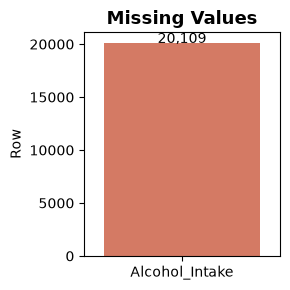

In [12]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.barplot(x=missing_summary.index, y=missing_summary['missing_count'], ax=ax, color='#e76f51')
ax.set_title('Missing Values', fontsize=13, fontweight='bold')
ax.set_ylabel('Row')
ax.set_xlabel('')
for i, v in enumerate(missing_summary['missing_count']):
    ax.text(i, v + 5, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**1.6 Display Duplicate Records**  
Check for duplicate records across all columns to prevent data redundancy that could affect the analysis.

In [14]:
dup_count = df.duplicated().sum()

print(f"Total duplicate rows (all columns): {dup_count}")

Total duplicate rows (all columns): 0


The evaluation reveals no duplicate records at the row level; therefore, no data removal is required.

**1.7 Display Class Distribution**  
Analyze the distribution of the target variable to check for class imbalance within the dataset.

In [15]:
class_counts = df['Heart_Disease'].value_counts()
class_percentages = df['Heart_Disease'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)
print("\nClass Percentages (%):")
print(class_percentages)

Class Counts:
Heart_Disease
0    26827
1    23173
Name: count, dtype: int64

Class Percentages (%):
Heart_Disease
0    53.654
1    46.346
Name: proportion, dtype: float64


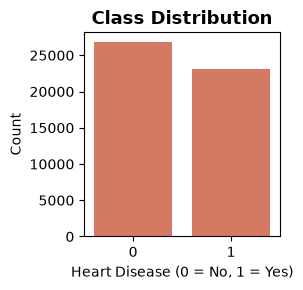

In [16]:
fig, ax = plt.subplots(figsize=(3, 3))
sns.countplot(x='Heart_Disease', data=df, ax=ax, color='#e76f51')
ax.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Heart Disease (0 = No, 1 = Yes)')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()